In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display plots inside notebook
%matplotlib inline

In [7]:
df = pd.read_csv(r"C:\Users\Ayesha\Downloads\Sample - Superstore.csv\Sample - Superstore.csv")

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
print("========== SALES STATISTICS ==========")

print("Mean:", df["Sales"].mean())

print("Median:", df["Sales"].median())

print("Mode:")
print(df["Sales"].mode())

print("Standard Deviation:", df["Sales"].std())

print("Variance:", df["Sales"].var())

print("Skewness:", df["Sales"].skew())

========== SALES STATISTICS ==========
Mean: 229.85800083049827
Median: 54.489999999999995
Mode:
0    12.96
Name: Sales, dtype: float64
Standard Deviation: 623.2451005086808
Variance: 388434.45530807565
Skewness: 12.97275234181623


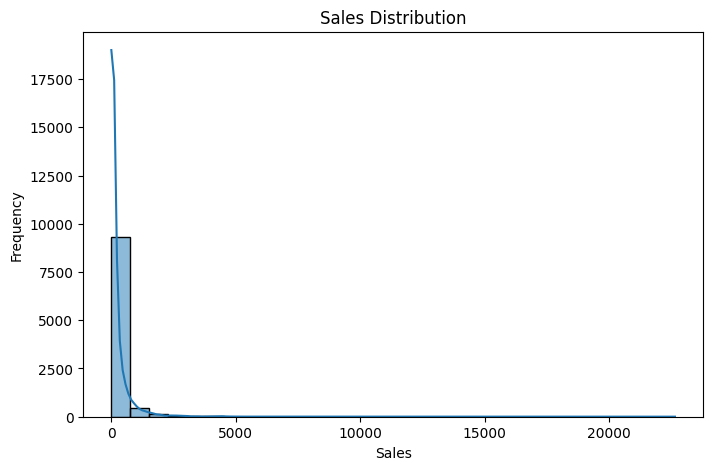

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=30, kde=True)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

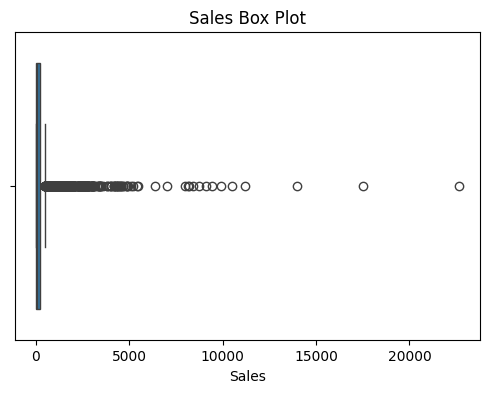

In [13]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Sales"])

plt.title("Sales Box Plot")

plt.show()

In [14]:
from scipy.stats import ttest_ind

# Sales for Furniture
furniture = df[df["Category"] == "Furniture"]["Sales"]

# Sales for Technology
technology = df[df["Category"] == "Technology"]["Sales"]

# Perform T-Test
t_stat, p_value = ttest_ind(furniture, technology)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -3.8430849029195886
P-Value: 0.0001233995294543413


In [15]:
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(df["Region"], df["Category"])

print(table)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(table)

print("\nChi-Square Statistic:", chi2)
print("P-Value:", p)

Category  Furniture  Office Supplies  Technology
Region                                          
Central         481             1422         420
East            601             1712         535
South           332              995         293
West            707             1897         599

Chi-Square Statistic: 3.661930938326572
P-Value: 0.7223155543986877


In [16]:
from scipy.stats import sem, t

sales = df["Sales"]

confidence = 0.95

mean = sales.mean()

margin = sem(sales) * t.ppf((1 + confidence) / 2, len(sales) - 1)

print("Mean Sales:", mean)
print("95% Confidence Interval:")
print(mean - margin, "to", mean + margin)

Mean Sales: 229.85800083049827
95% Confidence Interval:
217.63747489897534 to 242.0785267620212


In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [19]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum()
monthly_sales.head()

Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

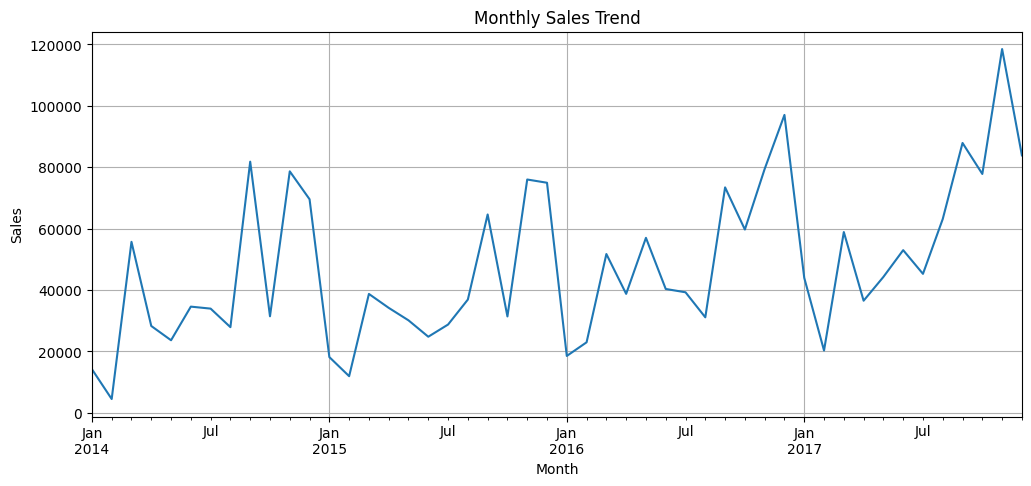

In [20]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

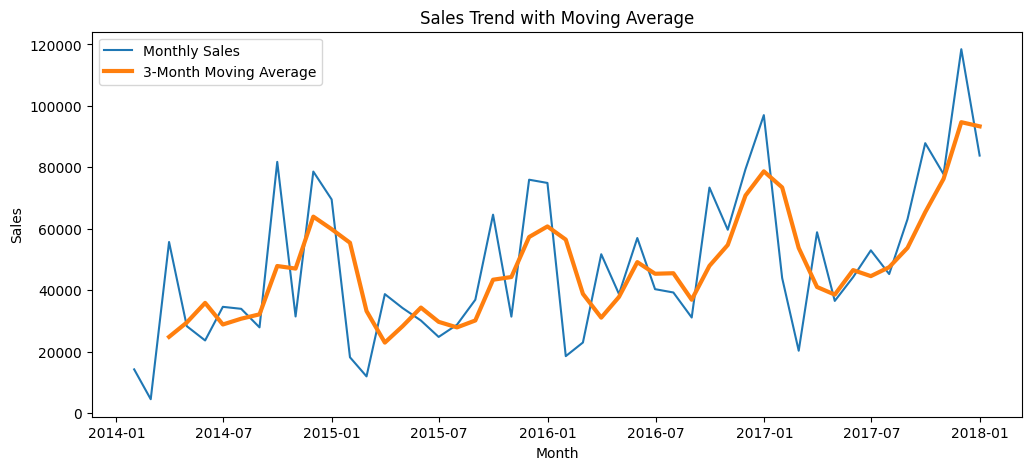

In [21]:
moving_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales, label="Monthly Sales")
plt.plot(moving_avg, label="3-Month Moving Average", linewidth=3)

plt.title("Sales Trend with Moving Average")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [22]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [23]:
X = df[["Sales", "Profit", "Quantity"]]

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [26]:
print(df["Cluster"].value_counts())

Cluster
0    6812
2    2857
3     309
1      16
Name: count, dtype: int64


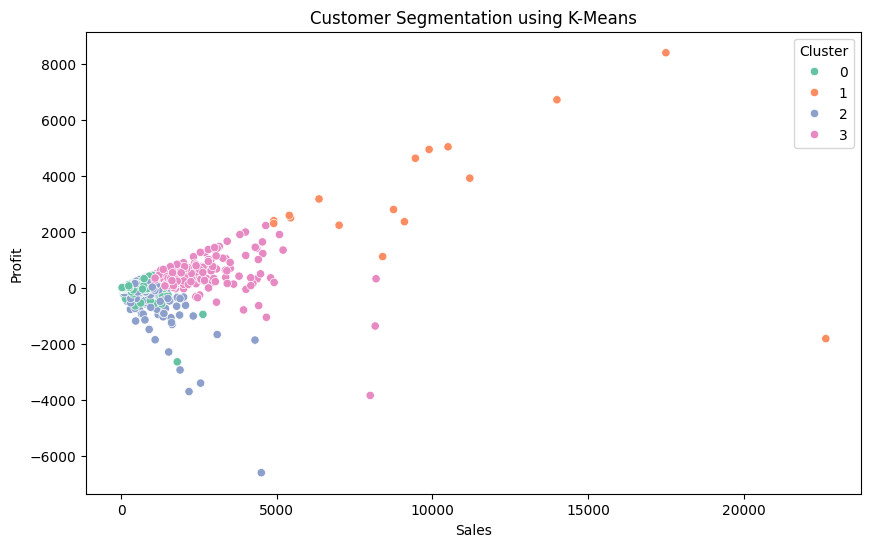

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

In [28]:
cluster_summary = df.groupby("Cluster")[["Sales", "Profit", "Quantity"]].mean()

print(cluster_summary)

               Sales       Profit  Quantity
Cluster                                    
0         125.762685    12.931178  2.554756
1        9714.344625  3334.327144  5.750000
2         224.380272     3.450882  6.479874
3        2084.211979   437.221466  6.035599


In [ ]:
Customer Segmentation Findings

• Cluster 0: Customers with moderate sales and profit.
• Cluster 1: High-value customers with higher sales.
• Cluster 2: Customers with lower sales and profit.
• Cluster 3: Customers with high quantity purchases.

These segments can help businesses target marketing strategies and improve customer engagement.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
X = df[["Quantity", "Discount"]]

y = df["Sales"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
predictions = model.predict(X_test)

In [34]:
print("R² Score:", r2_score(y_test, predictions))
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, predictions)))

R² Score: 0.03625634814946299
Mean Absolute Error: 274.98422630547105
Root Mean Squared Error: 754.5081631815635


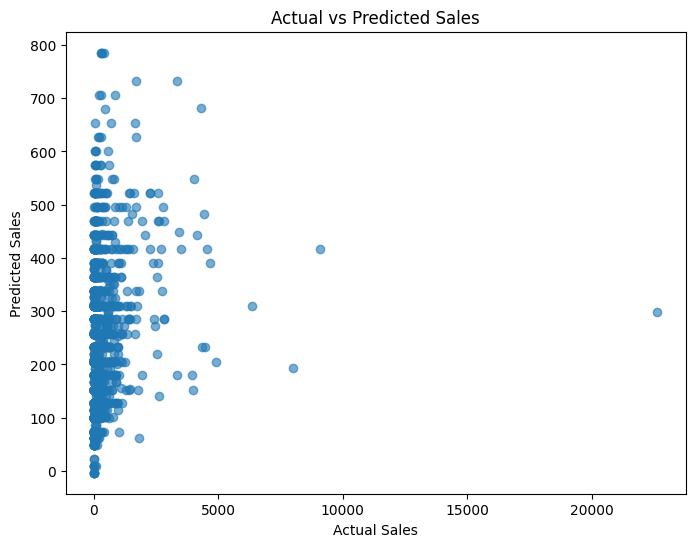

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions, alpha=0.6)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

## Conclusion

- Performed descriptive statistical analysis on the Superstore dataset.
- Conducted hypothesis testing using T-Test and Chi-Square Test.
- Analyzed sales trends using Time Series Analysis and Moving Average.
- Segmented customers using K-Means Clustering.
- Built a Linear Regression model to predict sales.
- Visualized results using Matplotlib and Seaborn.

This project demonstrates statistical analysis, customer segmentation, forecasting, and predictive analytics using Python.